#### TP1 Option Européenne - Aicha Meskar

In [10]:

import numpy as np # array
import pandas as pd
import numpy.linalg as lng # linear algebra
import matplotlib.pyplot as plt # plot functions
from scipy.stats import norm
import scipy.sparse as spl
from scipy.linalg import solve
import time
import sys # command sys.exit()




In [11]:
def phi(s,I):
    return np.maximum(K-s,0).reshape(I,1)

def uleft(t):
    return K*np.exp(-r*t)-Smin

def uright(t):
    return 0

def q(t,I):
        y=np.zeros((I,1))
        y[0] = (-alpha[0] + beta[0])*uleft(t)
        y[-1] = (-alpha[-1] - beta[-1])*uright(t)
        return y

In [12]:
def black_scholes(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    U = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return U

In [13]:
S, K, r, sigma, T = 80, 100, 0.1, 0.2, 1
black_scholes(S, K, T, r, sigma)

13.273662978769558

In [16]:
# Paramètres financiers globaux (passez-les comme arguments si besoin)
Smax, Smin, K, r, sigma, T = 200, 0, 100, 0.1, 0.2, 1
def schemas(I, schema, r, sigma, K, T, Smin, Smax):
    # Déterminer N en fonction du schéma
    if schema == "EE":
        N = I**2 // 10  # Schéma explicite nécessite plus de pas temporels pour la stabilité
    else:
        N = I//10

    # Discrétisation
    h = (Smax - Smin) / (I + 1)  
    s = Smin + h * np.arange(1, I + 1) 
    dt = T / N  
    Id = np.eye(I)

    

    # Construction de la matrice A
    A = np.zeros((I, I))
    alpha = 0.5 * sigma**2 * s**2 / h**2
    beta = r * s / (2 * h)

    for k in range(I):
        A[k][k] = 2 * alpha[k] + r
        if k < I - 1:
            A[k][k + 1] = -alpha[k] - beta[k]
        if k > 0:
            A[k][k - 1] = -alpha[k] + beta[k]

    
    U=phi(s, I)

    def q(t):
        q = np.zeros(I)
        q[0] = (-alpha[0] + beta[0]) * uleft(t)
        q[-1] = (-alpha[-1] - beta[-1]) * uright(t)
        return q

    # Application du schéma sélectionné
    if schema == "EE":
        for n in range(N):
            t = (n+1) * dt
            v = q(t)
            U = U - dt * (A @ U + v)

    elif schema == "EI":
        for n in range(N):
            t = (n + 1) * dt
            v = q(t)
            b = U - v * dt
            M = Id + dt * A
            U = solve(M, b)

    elif schema == "CN":
        M_left = Id + dt / 2 * A
        M_right = Id - dt / 2 * A
        for n in range(N):
            t = (n + 1) * dt
            v = q(t)
            b = M_right @ U - dt / 2 * v
            U = solve(M_left, b)

    else:
        raise ValueError("Schéma non reconnu : choisir 'EE', 'EI' ou 'CN'.")
    return s,h,U

    

In [17]:
schemas(50, "EE", r, sigma, K, T, Smin, Smax)
schemas(50, "EI", r, sigma, K, T, Smin, Smax)
schemas(50, "CN", r, sigma, K, T, Smin, Smax)


(array([  3.92156863,   7.84313725,  11.76470588,  15.68627451,
         19.60784314,  23.52941176,  27.45098039,  31.37254902,
         35.29411765,  39.21568627,  43.1372549 ,  47.05882353,
         50.98039216,  54.90196078,  58.82352941,  62.74509804,
         66.66666667,  70.58823529,  74.50980392,  78.43137255,
         82.35294118,  86.2745098 ,  90.19607843,  94.11764706,
         98.03921569, 101.96078431, 105.88235294, 109.80392157,
        113.7254902 , 117.64705882, 121.56862745, 125.49019608,
        129.41176471, 133.33333333, 137.25490196, 141.17647059,
        145.09803922, 149.01960784, 152.94117647, 156.8627451 ,
        160.78431373, 164.70588235, 168.62745098, 172.54901961,
        176.47058824, 180.39215686, 184.31372549, 188.23529412,
        192.15686275, 196.07843137]),
 3.9215686274509802,
 array([[ 8.78589140e+01,  8.92225769e+01,  8.92225769e+01, ...,
          8.92225769e+01,  8.92225769e+01,  8.92225769e+01],
        [ 8.12712691e+01,  8.26149559e+01,  8.2

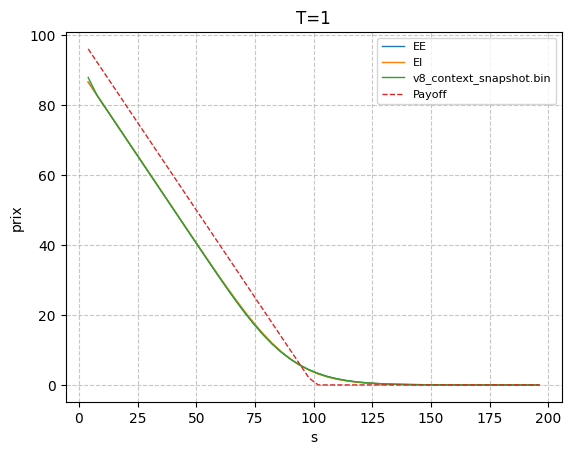

In [18]:
plt.plot(s1, U1, label="EE", linewidth=1)
plt.plot(s2, U2, label="EI", linewidth=1)
plt.plot(s3, U3, label="v8_context_snapshot.bin", linewidth=1)
plt.plot(s1,phi(s1,50), label="Payoff", linestyle="--", linewidth=1)
plt.xlabel("s")
plt.ylabel("prix")
plt.title("T=1")
plt.legend(fontsize=8)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [19]:
def test_numerique(mesh_size, schema):
    Ubar = 0
    e = []
    l = []
    m = [0]
    interp = []
    cpu_times = []
    errex=[]

    BS=black_scholes(S, K, T, r, sigma)

    for i in mesh_size:
        start_time = time.perf_counter()  # Mesure du temps plus précise
        s, h, U = schemas(i, schema)
        j = np.searchsorted(s, 80) - 1
        Ubar1 = ((s[j + 1] - 80) / h) * U[j] + ((80 - s[j]) / h) * U[j + 1]
        interp.append(Ubar1)

        if Ubar == 0:
            e.append(0)  # Pas d'erreur pour la première itération
            errex.append(0)
        else:
            e.append(abs(Ubar1 - Ubar))
            errex.append(abs(Ubar1-BS))
        Ubar = Ubar1
        l.append(h)

        end_time = time.perf_counter()  # Fin du temps CPU
        cpu_time = end_time - start_time
        cpu_times.append(cpu_time)

    for k in range(1, len(e)):
        if e[k-1]> 0 and e[k] > 0:  # Vérifie que les erreurs sont définies
            num = np.log(e[k-1] / e[k])
            den = np.log(l[k-1] / l[k])
            alphak = num / den
        else:
            alphak = 0  # Indéfini si erreur nulle
        m.append(alphak)

    data = {
        "I": mesh_size,
        "N": [i // 10 for i in mesh_size],
        "U(s)": interp,
        "error": e,
        "alpha": m,
        "errex":errex,
        "tcpu": cpu_times,
    }
    df = pd.DataFrame(data)

    print(df)


In [20]:
mesh_size = [10, 20, 40, 80, 160]
test_numerique(mesh_size, "EE")
test_numerique(mesh_size, "EI")
test_numerique(mesh_size, "CN")

TypeError: schemas() missing 6 required positional arguments: 'r', 'sigma', 'K', 'T', 'Smin', and 'Smax'